## <font color="blue"><b> DPO Demonstration</b></font>

### <font color="maroon"><b>Objectives:
-- Understand Direct Preference Optimization (DPO) - Dataset formats & Implementation </b></font>


### <font color="blue">**Step 0: Import packages and Seed setting**</font>

In [ ]:
import math
import torch
import numpy as np
import random
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForCausalLM, AutoTokenizer
from datasets import load_dataset
import matplotlib.pyplot as plt

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

### <font color="blue">**Step 1: Define Configurations**</font>

In [ ]:
MODEL_ID   = "Qwen/Qwen2-0.5B-Instruct"
BETA       = 0.1  # specific to DPO
LR         = 5e-7
EPOCHS     = 2
BATCH_SIZE = 32
MAX_LEN    = 128
N_TRAIN    = 500
N_VAL      = 100
N_TEST     = 100
DEVICE     = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


### <font color="blue"><b>Step 2: DPO Loss Intuition - Hand-coded example </b></font>

*   pol\_c → Log probability of the chosen response under the policy model
*   pol\_r → Log probability of the rejected response under the policy model
*   ref\_c → Log probability of the chosen response under the reference model
*   ref\_r → Log probability of the rejected response under the reference model

beta → Controls how strongly the policy should move away from the reference model

In [ ]:
def dpo_loss_scalar(pol_c, pol_r, ref_c, ref_r, beta=0.1):
    reward_chosen   = beta * (pol_c - ref_c)      # reward of chosen
    reward_rejected = beta * (pol_r - ref_r)      # reward of rejected

    margin = reward_chosen - reward_rejected

    # DPO loss: -log(sigmoid(margin))
    return -F.logsigmoid(torch.tensor(margin)).mean()

print("--- micro-example ---")
# (1) At init, policy == reference, so every reward is 0 -> margin 0 -> ln 2.
print("init (policy==ref):",dpo_loss_scalar(-2, -3, -2, -3), "  <- must equal ln2 =", round(math.log(2), 6))
# (2) Policy prefers chosen MORE than reference does -> loss drops below ln2.
print("policy favors chosen:", dpo_loss_scalar(0, -5, -2, -3), " (< ln2, good)")
# (3) Policy prefers REJECTED -> loss rises above ln2 (model being punished).
print("policy favors rejected:", dpo_loss_scalar(-3, -1, -2, -3), " (> ln2, bad)")

--- micro-example ---
init (policy==ref): tensor(0.6931)   <- must equal ln2 = 0.693147
policy favors chosen: tensor(0.5130)  (< ln2, good)
policy favors rejected: tensor(0.8544)  (> ln2, bad)


### <font color="blue"> <b>Step 3: Data Preparation for DPO (prompt, chosen, rejected)</b></font>

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

raw = load_dataset("trl-lib/ultrafeedback_binarized")
print(raw)

# Printing first sample of train split of the dataset
print("-----------------------------")
print(raw["train"][0].keys())
print("-----------------------------")
print(raw["train"][0]["chosen"])
print("-----------------------------")
print(raw["train"][0]["rejected"])
print("-----------------------------")
print(raw["train"][0]["score_chosen"])
print("-----------------------------")
print(raw["train"][0]["score_rejected"])

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.29k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.14MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/62135 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['chosen', 'rejected', 'score_chosen', 'score_rejected'],
        num_rows: 62135
    })
    test: Dataset({
        features: ['chosen', 'rejected', 'score_chosen', 'score_rejected'],
        num_rows: 1000
    })
})
-----------------------------
dict_keys(['chosen', 'rejected', 'score_chosen', 'score_rejected'])
-----------------------------
[{'content': 'Use the pygame library to write a version of the classic game Snake, with a unique twist', 'role': 'user'}, {'content': "Sure, I'd be happy to help you write a version of the classic game Snake using the pygame library! Here's a basic outline of how we can approach this:\n\n1. First, we'll need to set up the game display and create a game object that we can use to handle the game's state.\n2. Next, we'll create the game's grid, which will be used to represent the game board. We'll need to define the size of the grid and the spaces within it.\n3. After that, we'll create the snake 

In [ ]:
def to_triple(ex):
    prompt_msgs   = ex["chosen"][:-1]                       # except final assistant turn
    prompt_text   = tokenizer.apply_chat_template(prompt_msgs, tokenize=False, add_generation_prompt=True)
    chosen_text   = ex["chosen"][-1]["content"]
    rejected_text = ex["rejected"][-1]["content"]
    return {"prompt": prompt_text, "chosen": chosen_text, "rejected": rejected_text}

from textwrap import fill
example = to_triple(raw["train"][0])
print(fill(example["prompt"], width=100))
print("------------------------------------")
print(fill(example["chosen"], width=100))
print("------------------------------------")
print(fill(example["rejected"], width=100))

<|im_start|>system You are a helpful assistant.<|im_end|> <|im_start|>user Use the pygame library to
write a version of the classic game Snake, with a unique twist<|im_end|> <|im_start|>assistant
------------------------------------
Sure, I'd be happy to help you write a version of the classic game Snake using the pygame library!
Here's a basic outline of how we can approach this:  1. First, we'll need to set up the game display
and create a game object that we can use to handle the game's state. 2. Next, we'll create the
game's grid, which will be used to represent the game board. We'll need to define the size of the
grid and the spaces within it. 3. After that, we'll create the snake object, which will be used to
represent the player's movement. We'll need to define the size of the snake and the speed at which
it moves. 4. We'll also need to create a food object, which will be used to represent the food that
the player must collect to score points. We'll need to define the location o

In [ ]:
# Build train, validation, and test splits.

def take(split, start, count):
    return [to_triple(raw[split][i]) for i in range(start, start + count)]

train_triples = take("train", 0, N_TRAIN)
val_triples   = take("train", N_TRAIN, N_VAL)
test_triples  = take("test", 0, N_TEST)

print(f"Train samples      : {len(train_triples)}")
print(f"Validation samples : {len(val_triples)}")
print(f"Test samples       : {len(test_triples)}")

print("\nExample Prompt:--------------------------------------------\n")
print(train_triples[0]["prompt"])

print("\nChosen Response:--------------------------------------------\n")
print(train_triples[0]["chosen"][:100])

print("\nRejected Response:--------------------------------------------\n")
print(train_triples[0]["rejected"][:100])

Train samples      : 500
Validation samples : 100
Test samples       : 100

Example Prompt:--------------------------------------------

<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
Use the pygame library to write a version of the classic game Snake, with a unique twist<|im_end|>
<|im_start|>assistant


Chosen Response:--------------------------------------------

Sure, I'd be happy to help you write a version of the classic game Snake using the pygame library! H

Rejected Response:--------------------------------------------

Sure, here's an example of how to write a version of Snake game with a unique twist using the Pygame


In [ ]:
class PrefDataset(Dataset):
    def __init__(self, triples): self.t = triples
    def __len__(self): return len(self.t)
    def __getitem__(self, i): return self.t[i]

def tokenize_pair(prompt, completion):
    p_ids = tokenizer(prompt,     add_special_tokens=False)["input_ids"]
    c_ids = tokenizer(completion, add_special_tokens=False)["input_ids"] + [tokenizer.eos_token_id]
    ids  = (p_ids + c_ids)[:MAX_LEN]
    mask = ([0] * len(p_ids) + [1] * len(c_ids))[:MAX_LEN]   # 1 = completion token
    return ids, mask

In [ ]:
ids, mask = tokenize_pair(train_triples[0]["prompt"], train_triples[0]["chosen"])

print("Input IDs of Prompt:\n", ids)
print("Length Input IDs Prompt:\n", len(ids))
print("\nChosen with Completion Mask:\n", mask)
print("\nLength Chosen with Completion Mask:\n", len(mask))

Input IDs of Prompt:
 [151644, 8948, 198, 2610, 525, 264, 10950, 17847, 13, 151645, 198, 151644, 872, 198, 10253, 279, 14699, 6733, 311, 3270, 264, 2319, 315, 279, 11416, 1809, 39656, 11, 448, 264, 4911, 26646, 151645, 198, 151644, 77091, 198, 39814, 11, 358, 4172, 387, 6247, 311, 1492, 498, 3270, 264, 2319, 315, 279, 11416, 1809, 39656, 1667, 279, 14699, 6733, 0, 5692, 594, 264, 6770, 21101, 315, 1246, 582, 646, 5486, 419, 1447, 16, 13, 5512, 11, 582, 3278, 1184, 311, 738, 705, 279, 1809, 3037, 323, 1855, 264, 1809, 1633, 429, 582, 646, 990, 311, 3705, 279, 1809, 594, 1584, 624, 17, 13, 9295, 11, 582, 3278, 1855, 279, 1809, 594, 5827, 11, 892, 686, 387, 1483, 311, 4009, 279, 1809, 4479, 13, 1205, 3278, 1184, 311, 6979, 279]
Length Input IDs Prompt:
 128

Chosen with Completion Mask:
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [ ]:
def collate(batch):
    def pack(which):
        seqs, masks = [], []
        for ex in batch:
            ids, m = tokenize_pair(ex["prompt"], ex[which])
            seqs.append(torch.tensor(ids))
            masks.append(torch.tensor(m))
        maxlen = max(len(s) for s in seqs)
        # before being filled
        input_ids = torch.full((len(seqs), maxlen), tokenizer.pad_token_id, dtype=torch.long)
        attn      = torch.zeros((len(seqs), maxlen), dtype=torch.long)
        comp_mask = torch.zeros((len(seqs), maxlen), dtype=torch.long)

        # actual filling/updating step
        for i, (s, m) in enumerate(zip(seqs, masks)):
            input_ids[i, :len(s)] = s
            attn[i, :len(s)]      = 1
            comp_mask[i, :len(m)] = m
        return input_ids, attn, comp_mask
    ch = pack("chosen")
    rj = pack("rejected")
    return ch, rj   # each is (input_ids, attn, comp_mask)

train_loader = DataLoader(PrefDataset(train_triples), batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate)
val_loader   = DataLoader(PrefDataset(val_triples),   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
test_loader  = DataLoader(PrefDataset(test_triples),  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate)
print("--- Loaders ready (chosen & rejected kept as separate tensors) ---\n")

--- Loaders ready (chosen & rejected kept as separate tensors) ---



```text
Sample
│
├── Chosen
│     ├── input_ids
│     ├── attention_mask
│     └── completion_mask
│
└── Rejected
      ├── input_ids
      ├── attention_mask
      └── completion_mask
```

In [ ]:
# Get the first batch
chosen, rejected = next(iter(train_loader))

# Unpack
ch_input_ids, ch_attn, ch_comp_mask = chosen
rj_input_ids, rj_attn, rj_comp_mask = rejected

print("=== CHOSEN ===")
print("Input IDs:\n", ch_input_ids)
print("\nAttention Mask:\n", ch_attn)
print("\nCompletion Mask:\n", ch_comp_mask)


print("\n=== REJECTED ===")
print("Input IDs:\n", rj_input_ids)
print("\nAttention Mask:\n", rj_attn)
print("\nCompletion Mask:\n", rj_comp_mask)

=== CHOSEN ===
Input IDs:
 tensor([[151644,   8948,    198,  ...,   2878,    279,  21424],
        [151644,   8948,    198,  ...,   7299,  60679,     11],
        [151644,   8948,    198,  ...,    320,     88,     17],
        ...,
        [151644,   8948,    198,  ...,   5562,     13,  31040],
        [151644,   8948,    198,  ...,     16,     25,    576],
        [151644,   8948,    198,  ..., 151643, 151643, 151643]])

Attention Mask:
 tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0]])

Completion Mask:
 tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 1, 1, 1],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])

=== REJECTED ===
Input IDs:
 tensor([[151644,   8948,    198,  ...,   2878,    279,  21424],
        

### <font color="blue"> <b>Step 4: Models: trainable POLICY + frozen REFERENCE</b></font>

In [ ]:
policy = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float32).to(DEVICE)
ref    = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype=torch.float32).to(DEVICE)
ref.eval() # frozen reference model
for p in ref.parameters():
    p.requires_grad_(False)
optimizer = torch.optim.AdamW(policy.parameters(), lr=LR)
print("--- policy (trainable) + reference (frozen) loaded ---\n")

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

--- policy (trainable) + reference (frozen) loaded ---



### <font color="maroon">**Illustration of the DPO Loss**

<img src="https://raw.githubusercontent.com/Rekha215/Demo-Images/refs/heads/main/DPO_loss.png" width="1000">

### <font color = "maroon"><b> The loss used in DPO is defined as follows:</b></font>

$$
\mathcal{L}_{\mathrm{DPO}}(\theta)
=
-\mathbb{E}_{(x,\,y^{+},\,y^{-})}
\left[
\log
\sigma
\left(
\beta
\left(
\log
\frac{\pi_{\theta}(y^{+}\mid x)}
{\pi_{\mathrm{ref}}(y^{+}\mid x)}
-
\log
\frac{\pi_{\theta}(y^{-}\mid x)}
{\pi_{\mathrm{ref}}(y^{-}\mid x)}
\right)
\right)
\right]
$$

where

- $x$ is the **prompt**.
- $y^{+}$ is the **preferred (chosen) completion**.
- $y^{-}$ is the **dispreferred (rejected) completion**.
- $\pi_{\theta}$ is the **policy model** being trained.
- $\pi_{\mathrm{ref}}$ is the **reference model** (kept fixed during training).
- $\sigma(\cdot)$ is the **sigmoid function**.
- $\beta > 0$ is a **temperature (scaling) hyperparameter** that controls the strength of the preference signal.

### <font color="blue"><b>Step: 5 Functions for Computing Sequence Log Probabilities and DPO Loss

### **Numerical Example — `sequence_logprobs()`**

Vocabulary size = 5  
Token IDs = `[0, 1, 2, 3, 4]`

```text
input_ids = [0, 1, 2, 3]
comp_mask = [0, 0, 1, 1]

# Step 1. Model output
logits =
[
    [1.0, 3.0, 0.5, 0.2, 0.1],
    [0.2, 0.5, 2.5, 0.3, 0.1],
    [0.1, 0.2, 0.3, 2.0, 0.5]
]

logits.shape = (1, 3, 5)

# 4 input tokens → 3 next-token predictions
# input token 0 → predicts token 1
# input token 1 → predicts token 2
# input token 2 → predicts token 3


# Step 2. Shift input_ids → labels
labels = input_ids[:, 1:]
       = [1, 2, 3]

# Step 3. Shift completion mask
mask = comp_mask[:, 1:]
     = [0, 1, 1]


# Step 4. Convert logits → log probabilities

logp = log_softmax(logits)

logp =
[
    [-2.30, -0.30, -2.80, -3.10, -3.20],
    [-2.62, -2.31, -0.61, -2.51, -2.72],
    [-2.36, -2.26, -2.16, -0.46, -1.96]
]


# Step 5. gather() → select the log probability
#    of the actual target token

labels = [1, 2, 3]

# Row 0 → target token 1 → logp[0][1] = -0.30
# Row 1 → target token 2 → logp[1][2] = -0.61
# Row 2 → target token 3 → logp[2][3] = -0.46

tok = [-0.30, -0.61, -0.46]


# Step 6. Apply completion mask

tok  = [-0.30, -0.61, -0.46]
mask = [ 0.00,  1.00,  1.00]

tok × mask = [0.00, -0.61, -0.46]

# Step 7. Sum only completion-token log probabilities

sequence_logprob
= 0.00 + (-0.61) + (-0.46) = -1.07

# Final : sequence_logprob = -1.07

In [ ]:
def sequence_logprobs(model, input_ids, attn, comp_mask):
    # Predict the next token at every position in the sequence.
    logits = model(input_ids=input_ids, attention_mask=attn).logits[:, :-1, :]
    # Shift input_ids to obtain the target (ground-truth) tokens.
    labels = input_ids[:, 1:]
    # Shift the completion mask to match the target tokens.
    mask = comp_mask[:, 1:].float()
    # Convert logits into log probabilities.
    logp = F.log_softmax(logits, dim=-1)
    # Select the log probability assigned to each correct target token.
    tok = logp.gather(-1, labels.unsqueeze(-1)).squeeze(-1)
    # Sum the log probabilities of only the completion tokens.
    return (tok * mask).sum(dim=-1)

In [ ]:
def dpo_step(chosen, rejected):
    (ci, ca, cm), (ri, ra, rm) = chosen, rejected
    # policy log-probs (grad flows)
    pol_c = sequence_logprobs(policy, ci, ca, cm)
    pol_r = sequence_logprobs(policy, ri, ra, rm)
    # reference log-probs (no grad)
    with torch.no_grad():
        ref_c = sequence_logprobs(ref, ci, ca, cm)
        ref_r = sequence_logprobs(ref, ri, ra, rm)

    reward_chosen   = BETA * (pol_c - ref_c)
    reward_rejected = BETA * (pol_r - ref_r)
    margin = reward_chosen - reward_rejected
    loss   = -F.logsigmoid(margin).mean()

    return loss, reward_chosen.mean(), reward_rejected.mean()

@torch.no_grad()
def eval_loss(loader):
    policy.eval()
    tot, n = 0.0, 0
    for ch, rj in loader:
        ch = tuple(t.to(DEVICE) for t in ch); rj = tuple(t.to(DEVICE) for t in rj)
        loss, *_ = dpo_step(ch, rj); tot += loss.item(); n += 1
    return tot / max(n, 1)
print("---loss + reward functions defined ---\n")

---loss + reward functions defined ---



### <font color="blue"><b>Step: 6 Training Pipeline</b></font>

In [ ]:
# ---- DPO training ----
import copy
PATIENCE = 2
hist = {
    "train_loss": [],
    "val_loss": [],
    "step_loss": [],
    "step_r_chosen": [],
    "step_r_rejected": [],
}

best_val = float("inf")
best_epoch = 0
best_state = copy.deepcopy(policy.state_dict())
epochs_no_improve = 0

for epoch in range(1, EPOCHS + 1):

    policy.train()
    running_loss = 0.0

    for chosen, rejected in train_loader:

        chosen = tuple(t.to(DEVICE) for t in chosen)
        rejected = tuple(t.to(DEVICE) for t in rejected)

        loss, r_chosen, r_rejected = dpo_step(chosen, rejected)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(policy.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item()

        hist["step_loss"].append(loss.item())
        hist["step_r_chosen"].append(r_chosen.item())
        hist["step_r_rejected"].append(r_rejected.item())

    train_loss = running_loss / len(train_loader)
    val_loss = eval_loss(val_loader)

    hist["train_loss"].append(train_loss)
    hist["val_loss"].append(val_loss)

    print(
        f"Epoch {epoch}: "
        f"Train Loss = {train_loss:.4f} | "
        f"Validation Loss = {val_loss:.4f}"
    )

    if val_loss < best_val:
        best_val = val_loss
        best_epoch = epoch
        best_state = copy.deepcopy(policy.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print("\nEarly stopping triggered.")
        break

# Restore the best model.
policy.load_state_dict(best_state)

print(f"\nBest model restored from epoch {best_epoch}.")

Epoch 1: Train Loss = 0.6888 | Validation Loss = 0.6741
Epoch 2: Train Loss = 0.5369 | Validation Loss = 0.6651

Best model restored from epoch 2.


### <font color="blue">**Step 7: DPO Training Curves**</font>

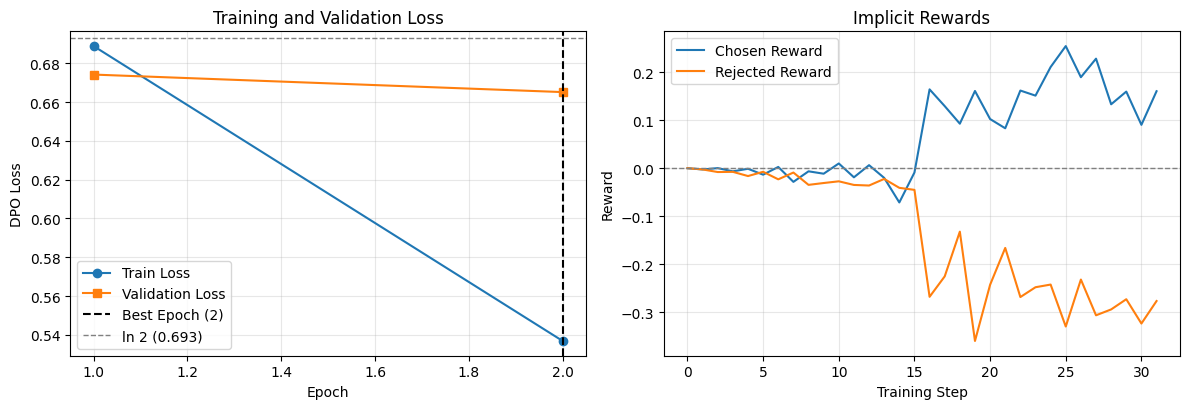

Saved -> dpo_teaching_curves.png


In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))

# -----------------------------------------------------------------------------
# Panel 1: Loss — per-step if single epoch, per-epoch if multiple
# -----------------------------------------------------------------------------
if len(hist["train_loss"]) > 1:
    # Multiple epochs: epoch-level train/val curves
    ep = list(range(1, len(hist["train_loss"]) + 1))
    ax[0].plot(ep, hist["train_loss"], "o-", label="Train Loss")
    ax[0].plot(ep, hist["val_loss"], "s-", label="Validation Loss")
    ax[0].axvline(best_epoch, ls="--", c="black", lw=1.5,
                  label=f"Best Epoch ({best_epoch})")
    if best_epoch < ep[-1]:
        ax[0].axvspan(best_epoch, ep[-1], color="red", alpha=0.08)
        ax[0].text(best_epoch + 0.1, max(hist["val_loss"]),
                   "Overfitting", color="red", fontsize=9, va="top")
    ax[0].set_xlabel("Epoch")
else:
    # Single epoch: show the per-step training loss (the real curve)
    ax[0].plot(hist["step_loss"], label="Train Loss (per step)", lw=1)
    # single validation point, drawn at the end of the epoch
    ax[0].scatter([len(hist["step_loss"]) - 1], hist["val_loss"],
                  color="C1", zorder=5, label="Validation Loss")
    ax[0].set_xlabel("Training Step")

ax[0].axhline(math.log(2), ls="--", c="gray", lw=1, label="ln 2 (0.693)")
ax[0].set_title("Training and Validation Loss")
ax[0].set_ylabel("DPO Loss")
ax[0].grid(alpha=0.3)
ax[0].legend()

# -----------------------------------------------------------------------------
# Panel 2: Implicit Rewards (per step — unchanged)
# -----------------------------------------------------------------------------
ax[1].plot(hist["step_r_chosen"], label="Chosen Reward")
ax[1].plot(hist["step_r_rejected"], label="Rejected Reward")
ax[1].axhline(0, ls="--", c="gray", lw=1)
ax[1].set_title("Implicit Rewards")
ax[1].set_xlabel("Training Step")
ax[1].set_ylabel("Reward")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.savefig("dpo_teaching_curves.png", dpi=130)
plt.show()
print("Saved -> dpo_teaching_curves.png")

### <font color="blue"> **Step 8: Test set Evaluation** </font>

In [ ]:
@torch.no_grad()
def final_test_eval(loader):
    policy.eval()
    tot_loss, tot_margin, n, total = 0.0, 0.0, 0, 0
    for ch, rj in loader:
        ch = tuple(t.to(DEVICE) for t in ch)
        rj = tuple(t.to(DEVICE) for t in rj)
        (ci, ca, cm), (ri, ra, rm) = ch, rj
        pol_c = sequence_logprobs(policy, ci, ca, cm)
        pol_r = sequence_logprobs(policy, ri, ra, rm)
        ref_c = sequence_logprobs(ref, ci, ca, cm)
        ref_r = sequence_logprobs(ref, ri, ra, rm)

        margin = BETA * ((pol_c - ref_c) - (pol_r - ref_r))
        tot_loss   += (-F.logsigmoid(margin)).mean().item(); n += 1
        tot_margin += margin.sum().item(); total += margin.size(0)

    print("\n================  FINAL TEST EVALUATION  ================")
    print(f"Test DPO loss        : {tot_loss / n:.4f}   (ln 2 = 0.6931)")
    print(f"Mean reward margin   : {tot_margin / total:+.4f}   (>0 means policy prefers chosen over rejected)")
    if tot_loss / n < math.log(2):
        print("Loss below ln 2 -> DPO improved preference over the reference.")
    else:
        print("Loss at/above ln 2 -> policy has not separated from the reference yet.")

final_test_eval(test_loader)


================  FINAL TEST EVALUATION  ================
Test DPO loss        : 0.6831   (ln 2 = 0.6931)
Mean reward margin   : +0.0466   (>0 means policy prefers chosen over rejected)
Loss below ln 2 -> DPO improved preference over the reference.


### <font color="blue"> **Step 9: Before vs After DPO on Test Samples** </font>

In [ ]:
@torch.no_grad()
def compare_models(sample_ids):

    policy.eval()
    ref.eval()

    for idx in sample_ids:

        ch, rj = next(iter(DataLoader(
            PrefDataset([test_triples[idx - 1]]),   # sample numbers start from 1
            batch_size=1,
            collate_fn=collate
        )))

        ch = tuple(t.to(DEVICE) for t in ch)
        rj = tuple(t.to(DEVICE) for t in rj)

        pol_c = sequence_logprobs(policy, *ch)
        pol_r = sequence_logprobs(policy, *rj)

        ref_c = sequence_logprobs(ref, *ch)
        ref_r = sequence_logprobs(ref, *rj)

        reward_chosen   = BETA * (pol_c - ref_c)
        reward_rejected = BETA * (pol_r - ref_r)
        reward_margin   = reward_chosen - reward_rejected

        print("=" * 80)
        print(f"Sample {idx}")
        print(f"Chosen Reward   : {reward_chosen.item():+.3f}")
        print(f"Rejected Reward : {reward_rejected.item():+.3f}")
        print(f"DPO Margin      : {reward_margin.item():+.3f}")

        if reward_margin > 0:
            print("Policy prefers the chosen response.")
        else:
            print("Policy still prefers the rejected response.")

In [ ]:
compare_models([13, 44, 52])

Sample 13
Chosen Reward   : +0.216
Rejected Reward : -0.792
DPO Margin      : +1.008
Policy prefers the chosen response.
Sample 44
Chosen Reward   : +0.103
Rejected Reward : -0.271
DPO Margin      : +0.374
Policy prefers the chosen response.
Sample 52
Chosen Reward   : -0.044
Rejected Reward : -0.204
DPO Margin      : +0.160
Policy prefers the chosen response.


In [ ]:
compare_models([2, 4, 6])

Sample 2
Chosen Reward   : +0.000
Rejected Reward : +0.000
DPO Margin      : +0.000
Policy still prefers the rejected response.
Sample 4
Chosen Reward   : +0.000
Rejected Reward : +0.000
DPO Margin      : +0.000
Policy still prefers the rejected response.
Sample 6
Chosen Reward   : -0.801
Rejected Reward : -0.110
DPO Margin      : -0.691
Policy still prefers the rejected response.


In [ ]:
# https://huggingface.co/docs/trl/dpo_trainer